In [1]:
import glob
from subprocess import run

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transit_time_dependence_plots import (extract_json, extract_json_tts_filter, extract_json_min_tts_filter, extract_json_tts_chi2_filter,plot_single_transit_time_histogram,
                                           prod_id_to_icm_id,extract_channel,extract_fit_params)

from refit_bad_tt_fits import merge_bins_reduceat
from transit_time_fit_functions import gaussian


from transit_time_file_paths import (geometry_files,mdom_tt_dir,
                                     run_picks_json,refit_json,
                                     empty_meas_json,transit_time_file)

import json

from pathlib import Path
home = str(Path.home())

In [18]:
    plotFolder: str = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/mdom_transit"

In [19]:
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"

In [20]:
def extract_json_site(transit_time_file,site_str,obj_key,filter_non_zero) -> list:
    '''
    Reads the json file with the list of DOMs and transit time measurements and returns a list of transit times
    and other data values
    for chi2, object key : "chi2"
    for transit time, object key:"mu"

    '''
    data_values = []
    hv_values = []    
    with open(transit_time_file, 'r') as f:
        data = json.load(f)
        for mdom, tt_data in data.items():
            if site_str in mdom:
                for ichannel in tt_data["transit_times"]:
                    for itt in tt_data["transit_times"][ichannel]:
                        if len(itt) > 0 and not np.isnan(itt[obj_key]) and not np.isnan(itt["applied HV"]):
                            data_values.append(itt[obj_key])
                            hv_values.append(itt["applied HV"])
    return data_values, hv_values

In [27]:
transit_times_single_per_pmt,hv_tt = extract_json_site(transit_times_single_gaussian_file,site_str="",obj_key="mu",filter_non_zero=False)
transit_times_spread_per_pmt,hv_tts = extract_json_site(transit_times_single_gaussian_file,site_str="",obj_key="sigma",filter_non_zero=False)

In [28]:
hv_list = hv_tts
sigma_list = transit_times_spread_per_pmt

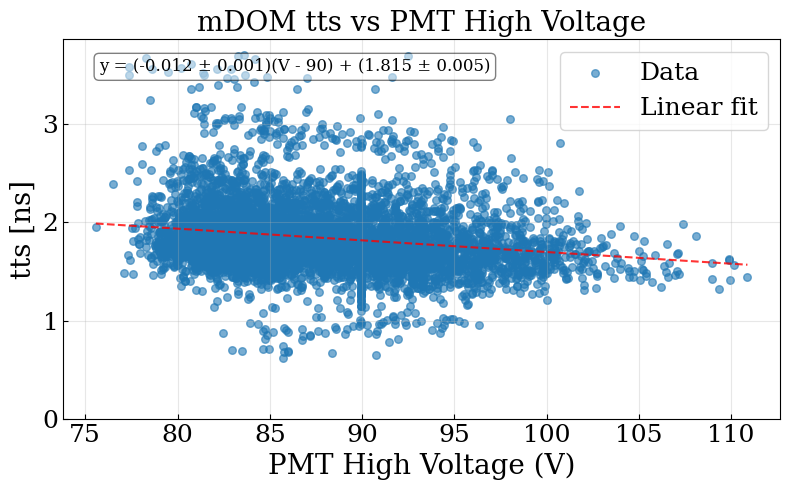

In [50]:
from scipy.optimize import curve_fit
import numpy as np

# Define linear function
def linear(x, m, b):
    return m * (x-90) + b

# Fit the data
popt, pcov = curve_fit(linear, hv_list, sigma_list)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))

# Create plot with fit
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])

ax.scatter(hv_list, sigma_list, alpha=0.6, s=30, label='Data')

# Plot fit line
x_fit = np.linspace(min(hv_list), max(hv_list), 100)
y_fit = linear(x_fit, m, b)
ax.plot(x_fit, y_fit, color='red', linestyle='--', alpha=0.8, label='Linear fit')

# Add fit equation and errors to plot
equation_text = f'y = ({m:.3f} ± {m_err:.3f})(V - 90) + ({b:.3f} ± {b_err:.3f})'
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
        fontsize=12)

ax.set_xlabel('PMT High Voltage (V)',fontsize=20)
ax.set_ylabel('tts [ns]', fontsize=20)
ax.set_title('mDOM tts vs PMT High Voltage', fontsize=20)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both', which='both', direction='in', labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(f'{plotFolder}/mdom_tts_vs_hv_fit.png', dpi=300)
plt.show()

In [30]:
hv_list = hv_tt
mu_list = transit_times_single_per_pmt

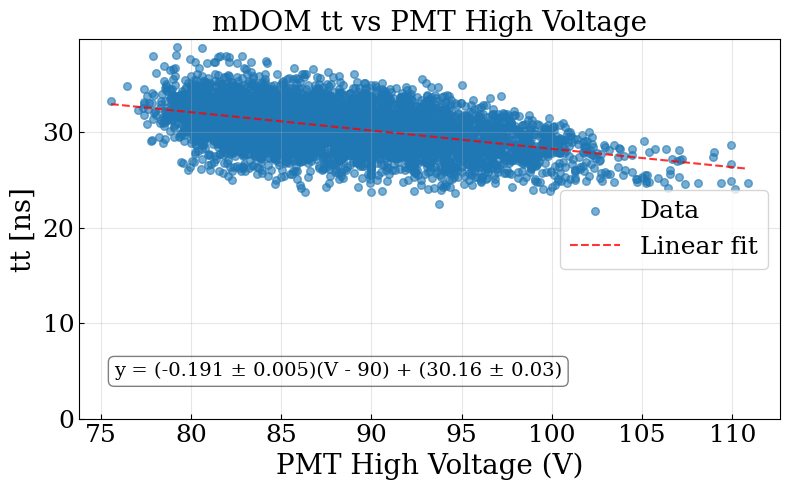

In [48]:
from scipy.optimize import curve_fit
import numpy as np

# Define linear function
def linear(x, m, b):
    return m * (x - 90) + b

# Fit the data
popt, pcov = curve_fit(linear, hv_list, mu_list)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))

# Create plot with fit
fig = plt.figure(figsize=(8,5))
gs = gridspec.GridSpec(nrows=1,ncols=1)
ax = fig.add_subplot(gs[0])

ax.scatter(hv_list, mu_list, alpha=0.6, s=30, label='Data')

# Plot fit line
x_fit = np.linspace(min(hv_list), max(hv_list), 100)
y_fit = linear(x_fit, m, b)
ax.plot(x_fit, y_fit, color='red', linestyle='--', alpha=0.8, label='Linear fit')

# Add fit equation and errors to plot
equation_text = f'y = ({m:.3f} ± {m_err:.3f})(V - 90) + ({b:.2f} ± {b_err:.2f})'
ax.text(0.05, 0.15, equation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
        fontsize=14)

ax.set_xlabel('PMT High Voltage (V)',fontsize=20)
ax.set_ylabel('tt [ns]', fontsize=20)
ax.set_title('mDOM tt vs PMT High Voltage', fontsize=20)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(axis='both', which='both', direction='in', labelsize=18)
ax.legend(fontsize=18)

plt.tight_layout()
plt.savefig(f'{plotFolder}/mdom_tt_vs_hv_fit.png', dpi=300)
plt.show()